# "Task 3: Heart Disease Prediction"

## Import Libraries

In [12]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler

## Load the dataset

In [3]:
# Load the Dataset
heart = pd.read_csv('HeartDiseaseTrain-Test.csv') 

## Clean the Dataset

In [6]:
# Clean and Inspect the Dataset
print("\nMissing Values:\n", heart.isnull().sum())
# Handle missing values: Impute with mean for numeric columns only
numeric_columns = heart.select_dtypes(include=['float64', 'int64']).columns
heart[numeric_columns] = heart[numeric_columns].fillna(heart[numeric_columns].mean())
# Summary statistics
print("\nDescriptive Statistics:\n", heart.describe())


Missing Values:
 age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

Descriptive Statistics:
                age  resting_blood_pressure  cholestoral  Max_heart_rate  \
count  1025.000000             1025.000000   1025.00000     1025.000000   
mean     54.434146              131.611707    246.00000      149.114146   
std       9.072290               17.516718     51.59251       23.005724   
min      29.000000               94.000000    126.00000       71.000000   
25%      48.000000              120.000000    211.00000      132.000000   
50%

## Perform EDA

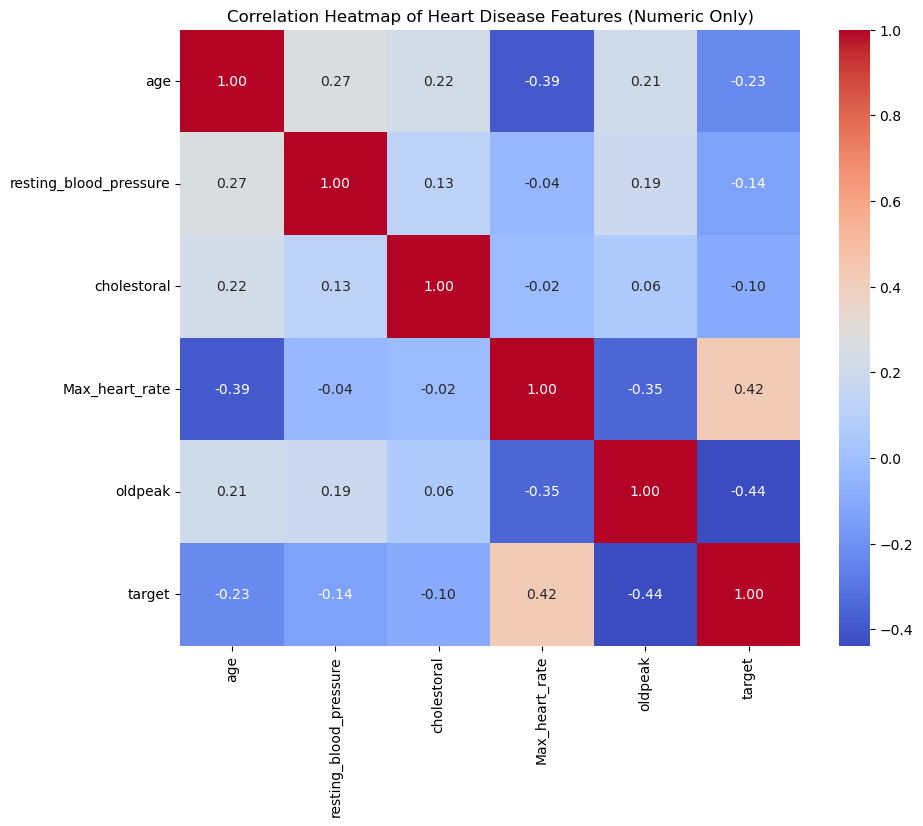

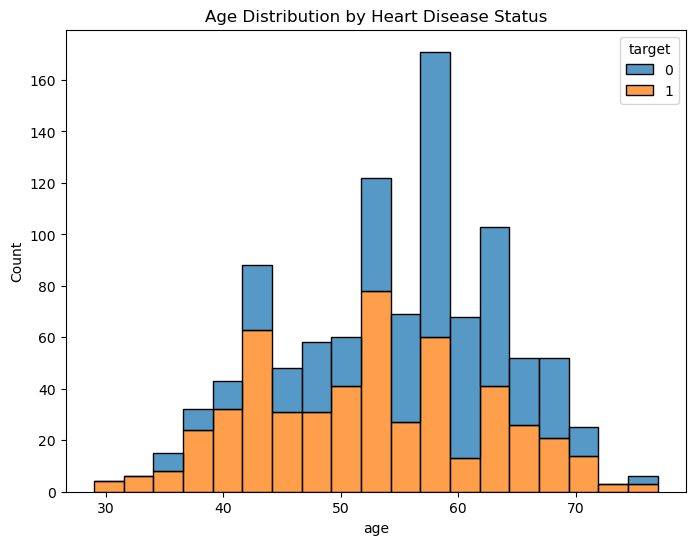

In [20]:
# Exploratory Data Analysis (EDA)
# Correlation heatmap (only for numeric columns)
plt.figure(figsize=(10, 8))
sns.heatmap(heart[numeric_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Heart Disease Features (Numeric Only)')
plt.savefig('correlation_heatmap.png')
plt.show()

# Distribution of age by target
plt.figure(figsize=(8, 6))
sns.histplot(data=heart, x='age', hue='target', multiple='stack')
plt.title('Age Distribution by Heart Disease Status')
plt.savefig('age_distribution.png')
plt.show()

# Preprocess categorical columns for modeling (e.g., convert 'Male'/'Female' to 0/1)
if 'sex' in heart.columns and heart['sex'].dtype == 'object':
    heart['sex'] = heart['sex'].map({'Male': 1, 'Female': 0})

# Convert other categorical columns to numeric (e.g., using get_dummies for 'cp', 'thal', etc.)
categorical_columns = heart.select_dtypes(include=['object']).columns
if len(categorical_columns) > 0:
    heart = pd.get_dummies(heart, columns=categorical_columns, drop_first=True)

## Train Model

In [13]:
# Train the Model
# Split data into features and target
X = heart.drop('target', axis=1)
y = heart['target']
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Model Evaluation , Confusion matrix , Accuracy , ROC curve


Accuracy: 0.7951219512195122


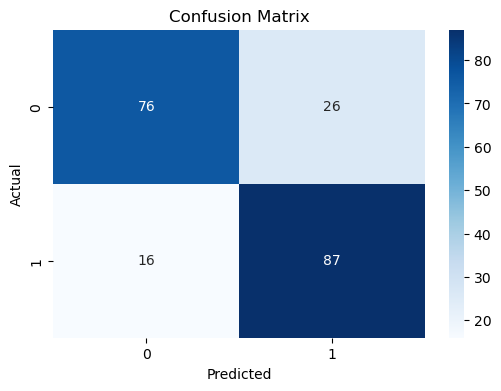

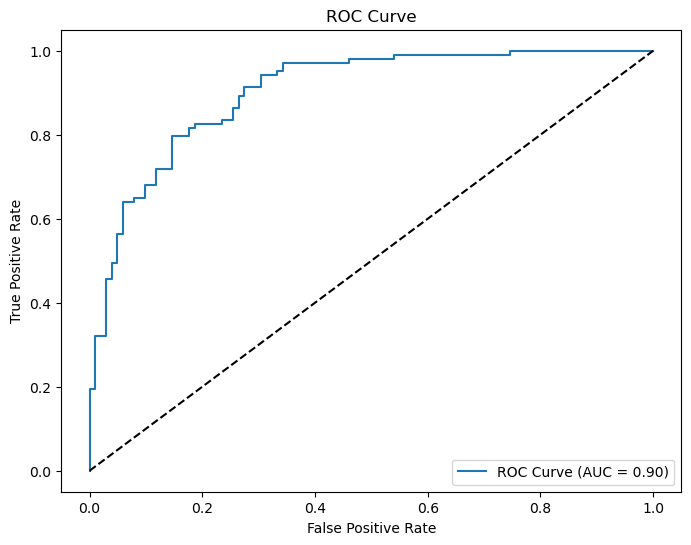

In [18]:
# Evaluate the Model
# Predictions
y_pred = model.predict(X_test)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')
plt.show()
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.savefig('roc_curve.png')
plt.show()


## Feature Importance (Logistic Regression Coefficients)

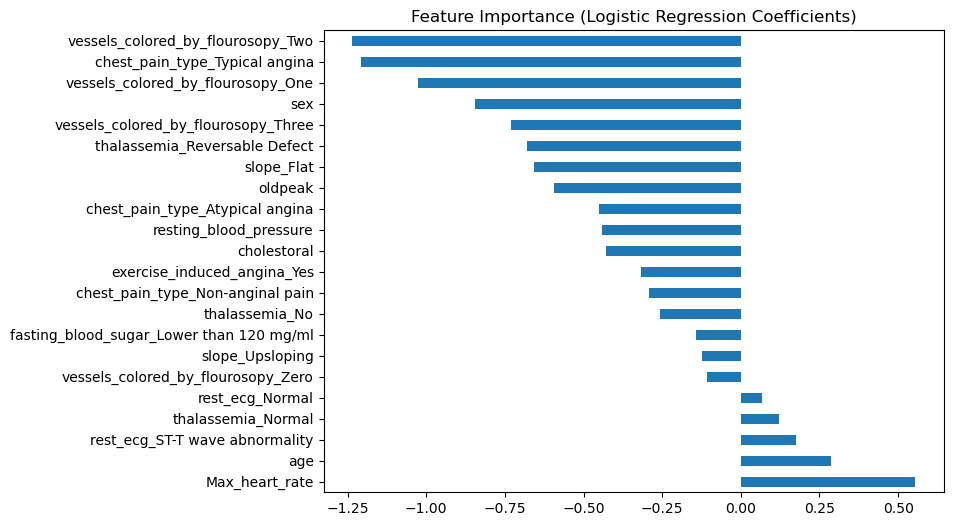

In [16]:

# Feature Importance
# Logistic Regression coefficients
feature_importance = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
feature_importance.plot(kind='barh')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.savefig('feature_importance.png')
plt.show()